In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
class frame_and_muid(object):
    def __init__(self, frame_id, muid):
        self.frame_id = frame_id
        self.muid = muid

    def __eq__(self, other):
        return (self.frame_id == other.frame_id) and (self.muid == other.muid)

    def __lt__(self, other):
        if((self.frame_id <= other.frame_id) and (self.muid < other.muid) or 
           (self.frame_id < other.frame_id) and (self.muid <= other.muid)):
            return True
        else:
            return False
    def __gt__(self, other):
        if((self.frame_id >= other.frame_id) and (self.muid > other.muid) or 
           (self.frame_id > other.frame_id) and (self.muid >= other.muid)):
            return True
        else:
            return False

    def __str__(self):
        return f"Frame ID: {self.frame_id}; MUID: {self.muid}"

In [3]:
def populate_dict(dict_name, filename):
    dict_name['filename'] = filename
    dict_name['messages'] = np.loadtxt(filename,delimiter=',',dtype=int,skiprows=1, usecols=(6,7,8,9,10,11,12,13),converters=lambda x: int(x,16))
    dict_name['timestamps'] = np.loadtxt(filename,delimiter=',',dtype=int,skiprows=1, usecols=(0))
    dict_name['ids'] = np.loadtxt(filename,delimiter=',',skiprows=1, dtype=int,usecols=(1),converters=lambda x : int(x,16))
    dict_name['hex_ids'] = np.loadtxt(filename,delimiter=',',dtype=str,skiprows=1, usecols=(1))
    dict_name['hex_messages'] = np.loadtxt(filename,delimiter=',',dtype=str,skiprows=1, usecols=(6,7,8,9,10,11,12,13))

In [4]:
def calculate_unique_message_id(dict_name):
    assert dict_name['messages'].shape[1] == 8
    dict_name['messages_unique_ids'] = np.zeros((dict_name['messages'].shape[0],),dtype=int)
    for i in range(8):
        dict_name['messages_unique_ids'] += dict_name['messages'][:,i]*16**(16-2*(i+1))
    # dict_name['messages_unique_ids'] += dict_name['ids']*16**16

In [5]:
def return_all_messages_for_frame(dict_name, frame_id,return_hex=False):
    if(return_hex):
        return dict_name['hex_messages'][np.argwhere(dict_name['ids'] == frame_id)[:,0]]
    else:
        return dict_name['messages'][np.argwhere(dict_name['ids'] == frame_id)[:,0]]

In [6]:
def return_all_frames_messages_for_muid_and_frame(dict_name, frame_id, muid,return_hex=False):
    indices = np.argwhere((dict_name['messages_unique_ids'] == muid)*(dict_name['ids'] == frame_id))[:,0]
    for index in indices:
        if(return_hex):
            return frame_and_muid(dict_name['hex_ids'][index],
                    dict_name['hex_messages'][index])
        else:
            return frame_and_muid(dict_name['ids'][index],
                    dict_name['messages'][index])

In [7]:
def return_frame_IDs_with_message_changes(dict_name):
    frame_ids = []
    for frame_id in np.unique(dict_name['ids']):
        unique_muids = np.unique(dict_name['messages_unique_ids'][np.argwhere(dict_name['ids'] == frame_id)[:,0]])
        if(len(unique_muids) > 1):
            frame_ids.append([frame_id,len(unique_muids)])
    return frame_ids

In [8]:
def return_frame_IDs_muids(dict_name, reject_muids = []):
    '''
    Return a list of all frame IDs and muids for a log.
    '''
    frames_and_muids = []
    for frame_id in np.unique(dict_name['ids']):
        unique_muids = np.unique(dict_name['messages_unique_ids'][np.argwhere(dict_name['ids'] == frame_id)[:,0]])
        for unique_muid in unique_muids:
            if(unique_muid not in reject_muids):
                indices = np.argwhere((dict_name['messages_unique_ids'] == unique_muid)*(dict_name['ids'] == frame_id))[:,0]
                frames_and_muids.append(frame_and_muid(frame_id,unique_muid))
    return frames_and_muids

In [39]:
def return_frame_IDs_muids_with_message_changes_in_timestamp_range(dict_name,timestamp_range, reject_muids = [], threshold = 10):
    '''
    This is a search for control signals, rather than physical sensors. Physical sensors can have a nearly infinite number of values.
    '''
    frames_and_muids = []
    for frame_id in np.unique(dict_name['ids']):
        unique_muids = np.unique(dict_name['messages_unique_ids'][np.argwhere(dict_name['ids'] == frame_id)[:,0]])
        if(len(unique_muids) < threshold):
            for unique_muid in unique_muids:
                if(unique_muid not in reject_muids):
                    indices = np.argwhere((dict_name['messages_unique_ids'] == unique_muid)*(dict_name['ids'] == frame_id))[:,0]
                    timestamps = dict_name['timestamps'][indices]
                    if(timestamps[0] > timestamp_range[0] and timestamps[-1] < timestamp_range[-1]):
                        frames_and_muids.append(frame_and_muid(frame_id,unique_muid))
    return frames_and_muids

In [10]:
def return_interesting_timestamps(dict_name,frame_ids):
    timestamps = []
    for frame_id in frame_ids:
        indices = np.argwhere(dict_name['ids'] == frame_id)[:,0]
        if(len(indices)):
            max_diff = np.argmax(np.abs(np.diff(dict_name['messages_unique_ids'][indices])))
            timestamps.append(dict_name['timestamps'][indices][max_diff])
    return timestamps

In [11]:
%ls

M-CAN_driving_with_nav_preconditioning_at_end_cleaned.csv
M-CAN_driving_with_nav_to_school_no_preconditioning.csv
M-CAN_start_nav_to_EA_parked_in_D_preconditioning_cleaned.csv
M-CAN_start_nav_to_school_parked_in_D.csv
MWE_cancel_preconditioning.csv
MWE_preconditioning.csv
parsing_MWE.ipynb


In [12]:
day_3_turn_on_2 = {}
day_3_nav_no_turn_on = {}
day_3_nav_no_turn_on_2 = {}
turn_on_at_end_2 = {}

In [14]:
populate_dict(day_3_turn_on_2, 'M-CAN_start_nav_to_EA_parked_in_D_preconditioning_cleaned.csv')
populate_dict(day_3_nav_no_turn_on, 'M-CAN_driving_with_nav_to_school_no_preconditioning_including_reroute.csv')
populate_dict(day_3_nav_no_turn_on_2, 'M-CAN_start_nav_to_school_parked_in_D.csv')
populate_dict(turn_on_at_end_2, 'M-CAN_driving_with_nav_preconditioning_at_end_cleaned.csv')

In [15]:
all_logs = [
day_3_turn_on_2,
day_3_nav_no_turn_on,
day_3_nav_no_turn_on_2,
turn_on_at_end_2
]

In [23]:
best_precon_logs = [day_3_turn_on_2, turn_on_at_end_2]
nav_control_logs = [day_3_nav_no_turn_on, day_3_nav_no_turn_on_2]

In [17]:
for log in all_logs:
    calculate_unique_message_id(log)

In [40]:
## 2AD, 2AC, 25D manually identified by dragz as likely precon related
muid_obj_lists = []
## may need to play with timestamp buffer a lot; a few-sec buffer DOES NOT
## reveal 4ED because of the 60-second timeout
timestamp_buffer = 5e6 # assumes us timestamps
for log in best_precon_logs:
    timestamps = return_interesting_timestamps(log,[int('25D',16), int('2AD',16), int('2AC',16)])
    timestamp_span = np.max(timestamps)-np.min(timestamps)
    timestamp_range = [np.min(timestamps)-timestamp_buffer,np.max(timestamps)+timestamp_buffer]
    muid_obj_lists.append(return_frame_IDs_muids_with_message_changes_in_timestamp_range(log, timestamp_range))
## intersect1d(): aggressive, gives the minimal list
## union via unique(concatenate()): conservative, maximal list
# precon_frames_muids = np.intersect1d(muid_obj_lists[0], muid_obj_lists[1])
precon_frames_muids = np.unique(np.concatenate(muid_obj_lists))

control_muid_obj_lists = []
for log in nav_control_logs:
    control_muid_obj_lists.append(return_frame_IDs_muids(log))
control_frames_muids = np.unique(np.concatenate(control_muid_obj_lists))

precon_diff = np.setdiff1d(precon_frames_muids, control_frames_muids)

for frame_muid in precon_diff:
    print(hex(frame_muid.frame_id))

0x123
0x237
0x25d
0x2ac
0x2fc
0x2fc
0x427
0xc7
0x25d
0x2ac
0x2ad
0x2d8
0x3a2
0x412
0x412
0x412
0x4e8


M-CAN_start_nav_to_EA_parked_in_D_preconditioning_cleaned.csv
0x4e8
0x4ec
0xc7


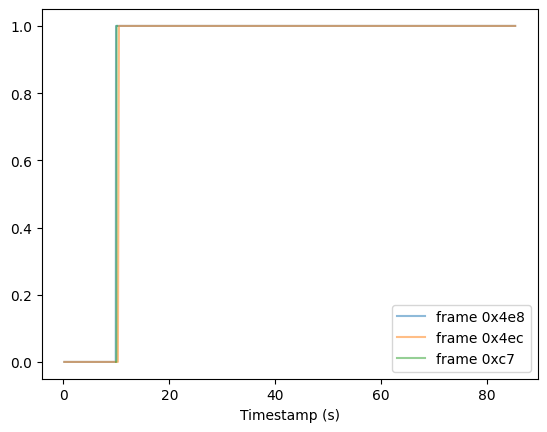

M-CAN_driving_with_nav_preconditioning_at_end_cleaned.csv
0x4e8
0x4ec
0xc7


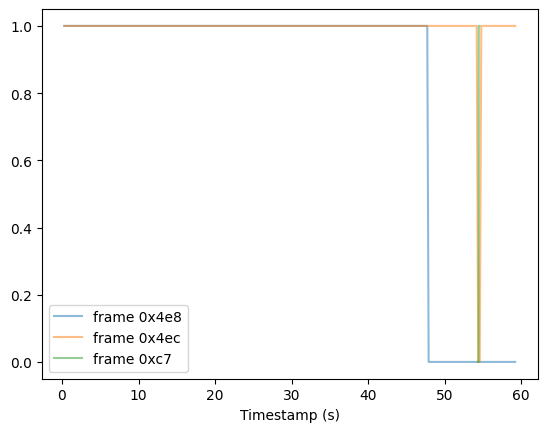

In [41]:
# test individual frame IDs via plotting
for log in best_precon_logs:
    print(log['filename'])
    for frame_id in [int('4E8', 16), int('4EC',16), int('0C7',16)]:
        print(hex(frame_id))
        indices = np.argwhere(log['ids'] == frame_id)[:,0]
        if(len(indices)):
            norm_vals = log['messages_unique_ids'][indices].astype(float)
            norm_vals -= norm_vals.min()
            norm_vals /= norm_vals.max()
            plt.plot(log['timestamps'][indices]/1e6,norm_vals,label=f'frame {hex(frame_id)}', alpha=0.5)
    plt.xlabel('Timestamp (s)')
    plt.legend()
    plt.show()